In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install kneed
from kneed import KneeLocator
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import plotly.express as px


import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

# Exploratory Data Analysis

In [64]:
# load dataset
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/student_dropout_behavior_dataset.csv"
df = pd.read_csv(url)
df.head()

,student_id,name,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
0,1,Kristina Vaughan,19,Male,8.0,5.7,7.4,5,NaN,30.0,36.5,2.57,12,4,6,1
1,2,Rodney Daniels,21,Male,10.0,7.9,4.1,5,NaN,25.4,33.0,2.40,12,1,6,5
2,3,Jose Nash,19,Female,7.5,1.2,0.3,5,NaN,14.4,24.8,2.99,12,0,6,0
3,4,Nicole Martin,21,Male,5.2,2.5,9.9,5,NaN,17.7,41.0,1.68,12,9,6,0
4,5,Shelby Smith,21,Female,5.9,6.3,2.0,5,NaN,23.8,31.0,2.53,12,7,6,4


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             300 non-null    int64  
 1   name                   300 non-null    object 
 2   age                    300 non-null    int64  
 3   gender                 300 non-null    object 
 4   quiz1_marks            300 non-null    float64
 5   quiz2_marks            300 non-null    float64
 6   quiz3_marks            300 non-null    float64
 7   total_assignments      300 non-null    int64  
 8   assignments_submitted  0 non-null      float64
 9   midterm_marks          300 non-null    float64
 10  final_marks            300 non-null    float64
 11  previous_gpa           300 non-null    float64
 12  total_lectures         300 non-null    int64  
 13  lectures_attended      300 non-null    int64  
 14  total_lab_sessions     300 non-null    int64  
 15  labs_a

In [66]:
print(df.shape)

(300, 16)


In [67]:
df.describe()

,student_id,age,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.0,0.0,300.000000,300.000000,300.000000,300.0,300.000000,300.0,300.000000
mean,150.500000,21.550000,7.254667,5.866667,5.469000,5.0,NaN,19.969000,37.375000,2.806033,12.0,6.013333,6.0,3.110000
std,86.746758,2.241483,1.611791,2.414786,2.711083,0.0,NaN,8.272229,11.796774,0.732694,0.0,3.726407,0.0,1.982676
min,1.000000,18.000000,2.800000,0.000000,0.000000,5.0,NaN,0.000000,0.000000,0.610000,12.0,0.000000,6.0,0.000000
25%,75.750000,20.000000,6.075000,4.000000,3.600000,5.0,NaN,14.225000,29.875000,2.327500,12.0,3.000000,6.0,1.000000
50%,150.500000,22.000000,7.300000,5.800000,5.600000,5.0,NaN,21.350000,39.600000,2.800000,12.0,6.000000,6.0,3.000000
75%,225.250000,23.000000,8.400000,7.700000,7.200000,5.0,NaN,27.425000,49.550000,3.320000,12.0,9.000000,6.0,5.000000
max,300.000000,25.000000,10.000000,10.000000,10.000000,5.0,NaN,30.000000,50.000000,4.000000,12.0,12.000000,6.0,6.000000


In [68]:
# Check for NaN values
df.isna().sum()

,0
student_id,0
name,0
age,0
gender,0
quiz1_marks,0
quiz2_marks,0
quiz3_marks,0
total_assignments,0
assignments_submitted,300
midterm_marks,0


In [69]:
# Nilai tiap column

for col in df.columns:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

=== student_id ===
student_id
300    1
1      1
2      1
3      1
4      1
      ..
17     1
16     1
15     1
14     1
13     1
Name: count, Length: 300, dtype: int64


=== name ===
name
Michael Davis    2
Mark Thomas      2
Amanda Perez     2
Haley Ramos      1
David Taylor     1
                ..
Jordan Bruce     1
Michael Diaz     1
John Hughes      1
Kevin Jones      1
Jill Salazar     1
Name: count, Length: 297, dtype: int64


=== age ===
age
23    45
22    44
21    39
18    38
24    37
19    34
25    33
20    30
Name: count, dtype: int64


=== gender ===
gender
Female    155
Male      145
Name: count, dtype: int64


=== quiz1_marks ===
quiz1_marks
10.0    24
7.5     13
5.7     11
7.6     10
7.4      9
        ..
9.5      1
4.7      1
9.7      1
3.9      1
4.0      1
Name: count, Length: 63, dtype: int64


=== quiz2_marks ===
quiz2_marks
10.0    19
5.2      7
4.6      7
6.5      7
7.7      7
        ..
1.3      1
8.7      1
9.1      1
0.0      1
1.4      1
Name: count, Length: 8

In [70]:
print(df.columns.tolist())

['student_id', 'name', 'age', 'gender', 'quiz1_marks', 'quiz2_marks', 'quiz3_marks', 'total_assignments', 'assignments_submitted', 'midterm_marks', 'final_marks', 'previous_gpa', 'total_lectures', 'lectures_attended', 'total_lab_sessions', 'labs_attended']


## Encoding

In [71]:
df_clean = df.copy()

In [72]:
df_clean = df_clean.drop(columns=['assignments_submitted'])  # semua NaN
df_clean = df_clean.drop(columns=['name']) # semua object

In [73]:
# Buat attendance rates
# karena total_lectures / total_lab_sessions konstan, kita tetap pakai denominator mereka
df_clean['lecture_attendance_rate'] = df_clean['lectures_attended'] / df_clean['total_lectures']
df_clean['lab_attendance_rate'] = df_clean['labs_attended'] / df_clean['total_lab_sessions']

In [74]:
# Encode gender
df_clean['gender_encoded'] = df_clean['gender'].map({'Male':1, 'Female':0})

In [75]:
# Check for NaN values
df_clean.isna().sum()

,0
student_id,0
age,0
gender,0
quiz1_marks,0
quiz2_marks,0
quiz3_marks,0
total_assignments,0
midterm_marks,0
final_marks,0
previous_gpa,0


## Visualization

### Correlation Heatmap of Student Performance Variables

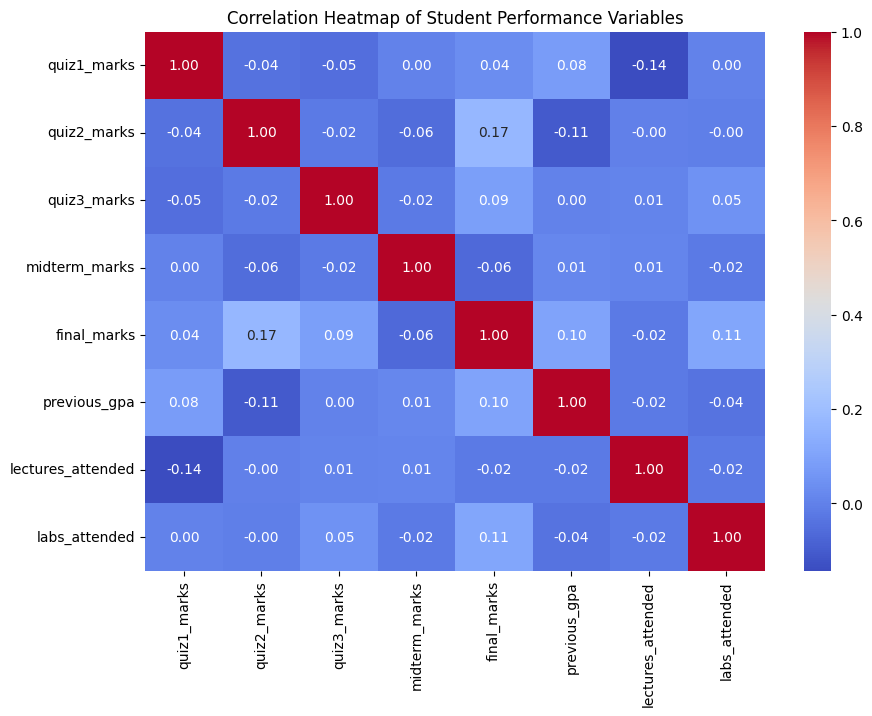

In [76]:
plt.figure(figsize=(10,7))
corr_cols = [
    'quiz1_marks','quiz2_marks','quiz3_marks',
    'midterm_marks','final_marks','previous_gpa',
    'lectures_attended','labs_attended'
]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Student Performance Variables")
plt.show()

Berdasarkan heatmap korelasi, terlihat bahwa hubungan antar variabel performa akademik seperti nilai kuis, midterm, final, dan GPA sebelumnya sangat lemah, dengan sebagian besar nilai korelasi mendekati nol. Hal ini menunjukkan bahwa tidak ada satu pun komponen penilaian yang secara konsisten bergerak searah atau mampu memprediksi performa pada komponen lainnya. Demikian pula, variabel kehadiran seperti jumlah pertemuan kuliah dan sesi lab yang dihadiri juga tidak menunjukkan korelasi berarti dengan nilai akademik. Temuan ini mengindikasikan bahwa performa mahasiswa dalam dataset ini sangat variatif dan dipengaruhi oleh berbagai faktor yang tidak linear, sehingga dosen maupun pihak akademik tidak dapat mengandalkan satu indikator saja seperti GPA atau tingkat kehadiran untuk mengidentifikasi mahasiswa berisiko. Kondisi ini menekankan pentingnya pendekatan analisis yang lebih komprehensif, seperti PCA atau clustering, untuk memahami pola belajar dan perilaku mahasiswa secara lebih mendalam.

### Scatter Plot Tot Cases per 1M vs Tot Deaths per 1M

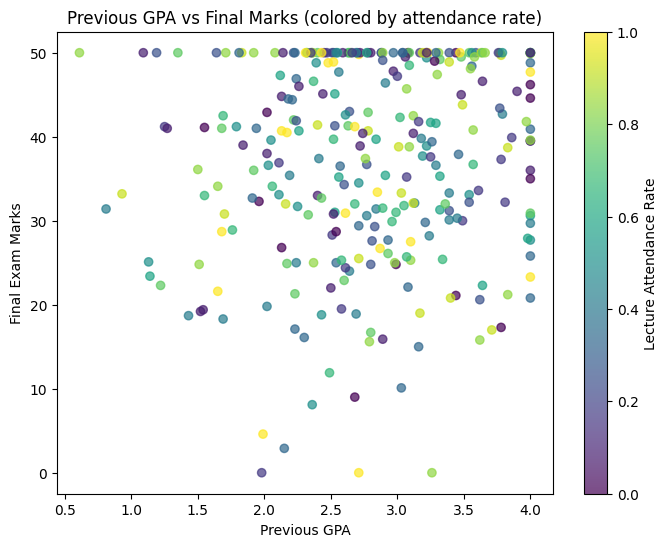

In [77]:
df['lecture_attendance_rate'] = df['lectures_attended'] / df['total_lectures']

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df['previous_gpa'], df['final_marks'],
    c=df['lecture_attendance_rate'], cmap='viridis', alpha=0.7
)
plt.colorbar(scatter, label='Lecture Attendance Rate')
plt.xlabel('Previous GPA')
plt.ylabel('Final Exam Marks')
plt.title('Previous GPA vs Final Marks (colored by attendance rate)')
plt.show()

Scatter plot antara previous GPA dan final exam marks menunjukkan penyebaran data yang luas tanpa pola linear yang jelas, menandakan bahwa GPA sebelumnya tidak secara langsung menentukan performa mahasiswa pada ujian final. Mahasiswa dengan GPA rendah masih dapat memperoleh nilai final yang tinggi, dan sebaliknya, menunjukkan bahwa performa akademik tidak semata-mata bergantung pada capaian sebelumnya. Ketika dimasukkan informasi attendance rate melalui pewarnaan data, pola yang muncul juga tidak memperlihatkan tren yang tegas; mahasiswa dengan tingkat kehadiran rendah maupun tinggi sama-sama tersebar di berbagai rentang nilai final. Hal ini menunjukkan bahwa kehadiran kuliah tidak secara otomatis berbanding lurus dengan capaian nilai akhir. Temuan ini memiliki implikasi penting bagi pengajaran: dosen perlu mengadopsi pendekatan yang lebih personal dan komprehensif dalam memahami kebutuhan mahasiswa, karena performa akhir dipengaruhi oleh kombinasi faktor yang kompleks, bukan hanya kehadiran maupun riwayat nilai sebelumnya. Pendekatan seperti ini penting untuk merancang intervensi yang lebih tepat sasaran bagi mahasiswa yang berisiko.

# Data Scaling

In [78]:
# Pilih fitur untuk PCA / clustering
features = [
    'quiz1_marks','quiz2_marks','quiz3_marks',
    'midterm_marks','final_marks','previous_gpa',
    'lecture_attendance_rate','lab_attendance_rate',
    'age','gender_encoded'
]
X = df_clean[features].copy()

In [79]:
X_scaled = StandardScaler().fit_transform(X)

# K-Means Clustering

In [80]:
from sklearn.cluster import KMeans

### Elbow Method K-Means

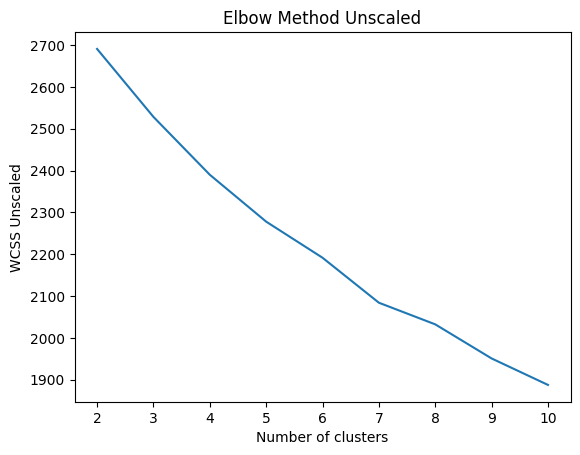

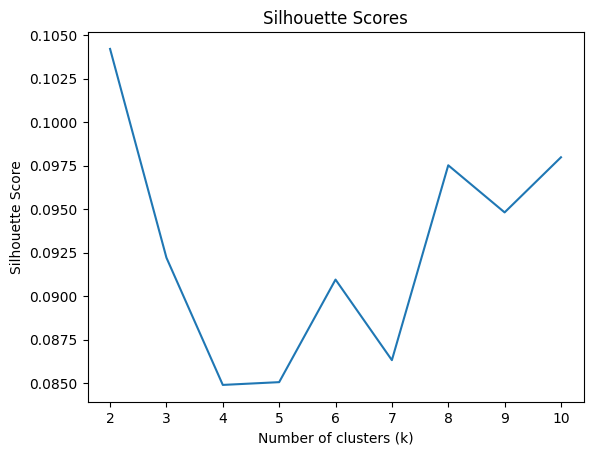

Optimal K (Elbow Method): 7
Optimal K (Silhouette Score) = 2
All Silhouette Scores: [np.float64(0.10420028108248014), np.float64(0.09221329477329945), np.float64(0.08490755874978625), np.float64(0.08506689677952926), np.float64(0.0909560115751052), np.float64(0.0863300880767991), np.float64(0.0975190153199701), np.float64(0.09481334261070604), np.float64(0.09797917442077889)]


In [81]:
wcss_kmeans = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    wcss_kmeans.append(kmeans.inertia_)

sil_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.plot(range(2, 11), wcss_kmeans)
plt.title('Elbow Method Unscaled')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS Unscaled')
plt.show()

plt.plot(range(2, 11), sil_scores)
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

clusters = range(2, 11)
knee_locator = KneeLocator(clusters, wcss_kmeans, curve="convex", direction="decreasing")
optimal_clusters = knee_locator.knee
print(f"Optimal K (Elbow Method): {optimal_clusters}")

best_k_sil = range(2, 11)[sil_scores.index(max(sil_scores))]
print(f"Optimal K (Silhouette Score) = {best_k_sil}")
print(f"All Silhouette Scores: {sil_scores}")

Berdasarkan hasil Elbow Method, titik siku (elbow) terlihat pada K = 7, yang menunjukkan bahwa penurunan nilai SSE mulai melambat setelah jumlah cluster mencapai tujuh. Namun demikian, pemilihan K tidak hanya mengandalkan Elbow Method saja, karena metode ini sering memberikan rekomendasi yang terlalu besar dalam kasus data yang variansnya sangat rendah antar fitur, seperti pada dataset ini. Ketika mempertimbangkan nilai Silhouette Score, hasil terbaik diperoleh pada K = 2, yang memiliki nilai silhouette paling tinggi dibandingkan K lain (meskipun nilai keseluruhannya tetap rendah). Silhouette Score yang lebih tinggi menandakan bahwa pemisahan antar cluster lebih jelas dan struktur cluster lebih stabil. Dengan demikian, meskipun Elbow Method mengarah ke K = 7, pemilihan jumlah cluster yang paling tepat secara matematis dan interpretatif adalah K = 2, karena menghasilkan cluster yang lebih terpisah dan lebih mudah dijelaskan dalam konteks analisis perilaku mahasiswa. Pendekatan ini juga lebih konsisten dengan karakteristik dataset yang memiliki korelasi lemah antar variabel, sehingga pola pemisahan alami dalam data cenderung membentuk sedikit cluster, bukan banyak cluster.

In [82]:
kmeans_sil = KMeans(n_clusters=best_k_sil, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_sil.fit(X_scaled)
wcss_kmeans.append(kmeans_sil.inertia_)

In [83]:
kmeans_elbow = KMeans(n_clusters=optimal_clusters, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_elbow.fit(X_scaled)
wcss_kmeans.append(kmeans_elbow.inertia_)

In [84]:
# Tambahkan cluster labels ke DataFrame asli
df_clean['Cluster_K-Means'] = kmeans_sil.labels_

# Cek hasil
df_clean.head()

,student_id,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended,lecture_attendance_rate,lab_attendance_rate,gender_encoded,Cluster_K-Means
0,1,19,Male,8.0,5.7,7.4,5,30.0,36.5,2.57,12,4,6,1,0.333333,0.166667,1,1
1,2,21,Male,10.0,7.9,4.1,5,25.4,33.0,2.40,12,1,6,5,0.083333,0.833333,1,1
2,3,19,Female,7.5,1.2,0.3,5,14.4,24.8,2.99,12,0,6,0,0.000000,0.000000,0,0
3,4,21,Male,5.2,2.5,9.9,5,17.7,41.0,1.68,12,9,6,0,0.750000,0.000000,1,1
4,5,21,Female,5.9,6.3,2.0,5,23.8,31.0,2.53,12,7,6,4,0.583333,0.666667,0,0


In [85]:
print(df_clean['Cluster_K-Means'].value_counts(dropna=False))

Cluster_K-Means
0    155
1    145
Name: count, dtype: int64


K-Means dengan K = 2, yang dipilih berdasarkan Silhouette Score tertinggi, menghasilkan pembagian data menjadi dua cluster besar yang lebih seimbang (155 dan 145 mahasiswa). Meskipun nilai silhouette keseluruhan rendah, K = 2 tetap menjadi pilihan yang lebih valid karena memberikan pemisahan yang paling jelas dan stabil antar cluster dibandingkan nilai K lainnya. Dengan hanya dua cluster, masing-masing kelompok dapat diprofilkan secara lebih tegas—misalnya kelompok mahasiswa berperforma tinggi versus kelompok performa rendah atau kelompok dengan engagement tinggi versus engagement rendah. Pendekatan ini jauh lebih mudah untuk diterjemahkan menjadi rekomendasi edukatif yang konkret dan actionable. Oleh karena itu, berdasarkan keseimbangan antara interpretabilitas, kestabilan cluster, dan nilai silhouette, K = 2 adalah pilihan optimal untuk analisis K-Means pada dataset ini.

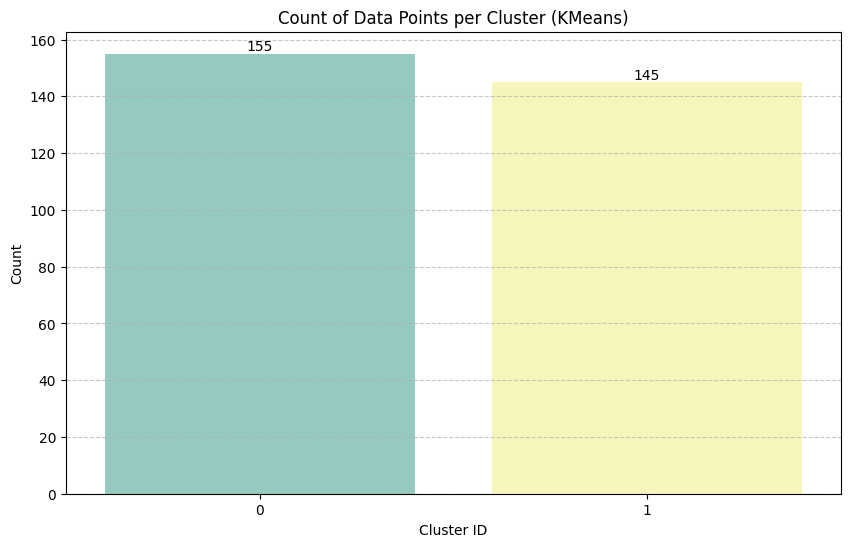

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung jumlah anggota per cluster
cluster_counts_kmeans = df_clean['Cluster_K-Means'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=cluster_counts_kmeans.index,
    y=cluster_counts_kmeans.values,
    hue=cluster_counts_kmeans.index,
    palette='Set3',
    legend=False
)

# Tambahkan label jumlah di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (KMeans)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [91]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_scaled, df_clean['Cluster_K-Means'])

print(f"Silhouette Score: {sil:.3f}")

Silhouette Score: 0.104


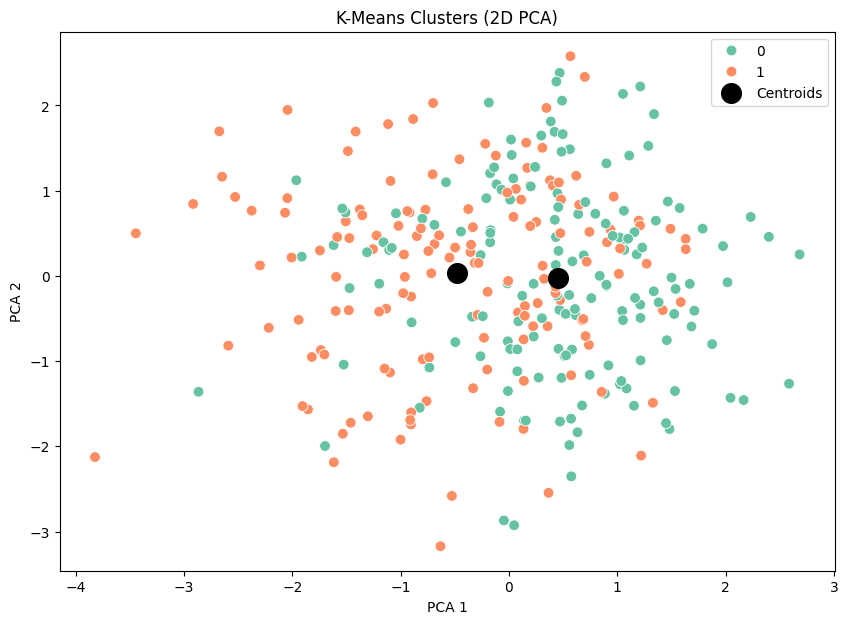

In [87]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Centroids di PCA space
centroids_pca = pca.transform(kmeans_sil.cluster_centers_)

# Plot
plt.figure(figsize=(10,7))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_sil.labels_, palette='Set2', s=60)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c='black', label='Centroids')
plt.title(f'K-Means Clusters (2D PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()


In [88]:
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

# Print results
print("Explained variance ratio per component:")
for i, val in enumerate(explained):
    print(f"PC{i+1}: {val:.4f}")

print("\nCumulative variance:")
for i, val in enumerate(cumulative):
    print(f"PC1–PC{i+1}: {val:.4f}")

Explained variance ratio per component:
PC1: 0.1288
PC2: 0.1214

Cumulative variance:
PC1–PC1: 0.1288
PC1–PC2: 0.2502


In [89]:
for i, (e, c) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1}: {e:.4f} | cumulative: {c:.4f}")

PC1: 0.1288 | cumulative: 0.1288
PC2: 0.1214 | cumulative: 0.2502


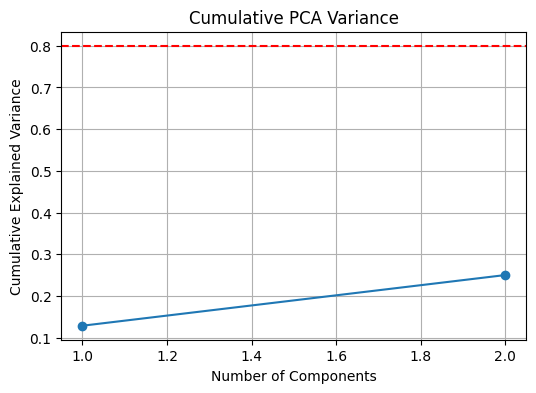

In [90]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker='o')
plt.axhline(0.80, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative PCA Variance')
plt.grid(True)
plt.show()


The cumulative PCA variance plot shows that the first two principal components capture only 25.02% of the total variance far below the commonly accepted threshold of 70–80% that is typically required to retain meaningful information from the original dataset. The red dashed line at the 0.80 level highlights how distant the current cumulative variance is from the desired range. This indicates that the structure of the dataset is spread across many different dimensions and cannot be adequately summarized using just two components. Therefore, while using two PCs is acceptable for visualization purposes, it is not appropriate for dimensionality reduction or downstream modeling. To determine the optimal number of components to keep, PCA should be recomputed with all available components so that the cumulative variance curve can be evaluated fully, allowing selection of the minimum number of PCs needed to reach at least 70–80% cumulative explained variance.

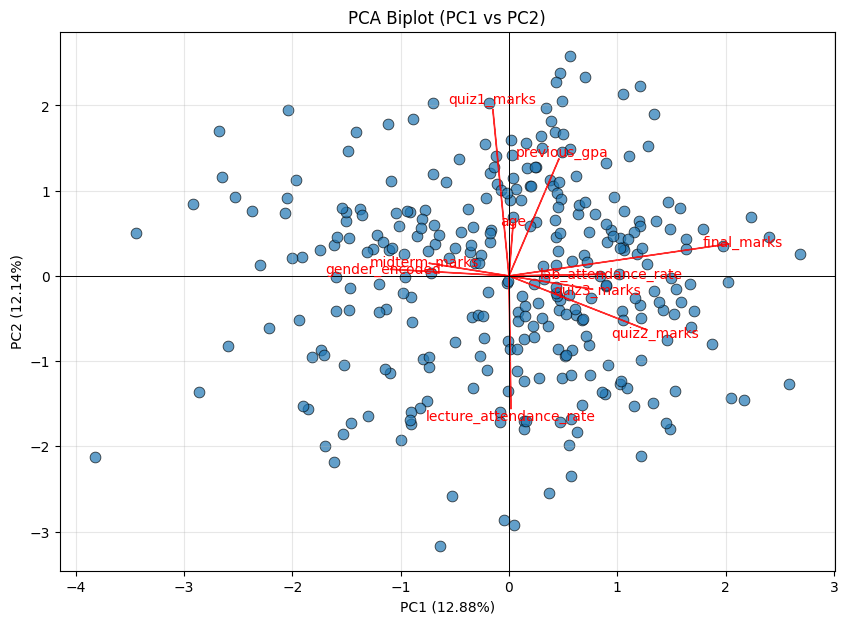

In [92]:
# Loadings (influence of each variable on each PC)
loadings = pca.components_.T
feature_names = X.columns

plt.figure(figsize=(10, 7))

# Scatter plot of student data
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    s=60,
    alpha=0.7,
    edgecolor='k'
)

# Plot loading vectors
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0,
              loadings[i, 0] * 3,
              loadings[i, 1] * 3,
              color='red',
              alpha=0.8,
              width=0.003
              )
    plt.text(loadings[i, 0] * 3.2,
             loadings[i, 1] * 3.2,
             feature,
             color='red',
             fontsize=10,
             ha='center', va='center')

plt.title("PCA Biplot (PC1 vs PC2)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.axhline(0, color='black', linewidth=0.7)
plt.axvline(0, color='black', linewidth=0.7)
plt.grid(True, alpha=0.3)
plt.show()

Interpretasi PC1 (Sumbu Horizontal) PC1 pada dasarnya merepresentasikan Performa Akademik Akhir dan Keaktifan Lab. Sumbu ini menunjukkan bahwa semakin ke kanan posisi seorang mahasiswa, semakin tinggi kecenderungan mereka memiliki nilai akhir (final_marks), nilai kuis lanjutan (quiz3_marks, quiz2_marks), dan tingkat kehadiran laboratorium (lab_attendance_rate). Variabel-variabel ini adalah yang paling penting dan berkontribusi paling besar (positif) terhadap PC1, sementara midterm_marks memiliki arah yang sedikit berlawanan.

Interpretasi PC2 (Sumbu Vertikal) PC2 merepresentasikan perbedaan karakteristik antara Pencapaian Awal/Historis dengan Kehadiran Kuliah. Sumbu positif (atas) didominasi oleh nilai kuis pertama (quiz1_marks) dan IPK sebelumnya (previous_gpa), yang menandakan kemampuan akademis awal. Sebaliknya, sumbu negatif (bawah) sangat kuat dipengaruhi oleh tingkat kehadiran kuliah (lecture_attendance_rate). Jadi, variabel terpenting untuk PC2 adalah quiz1_marks (faktor pendorong utama ke atas) dan lecture_attendance_rate (faktor pendorong utama ke bawah).

# Hierarchical Agglomerative Clustering

Skipping Ward linkage with Manhattan metric (not supported).


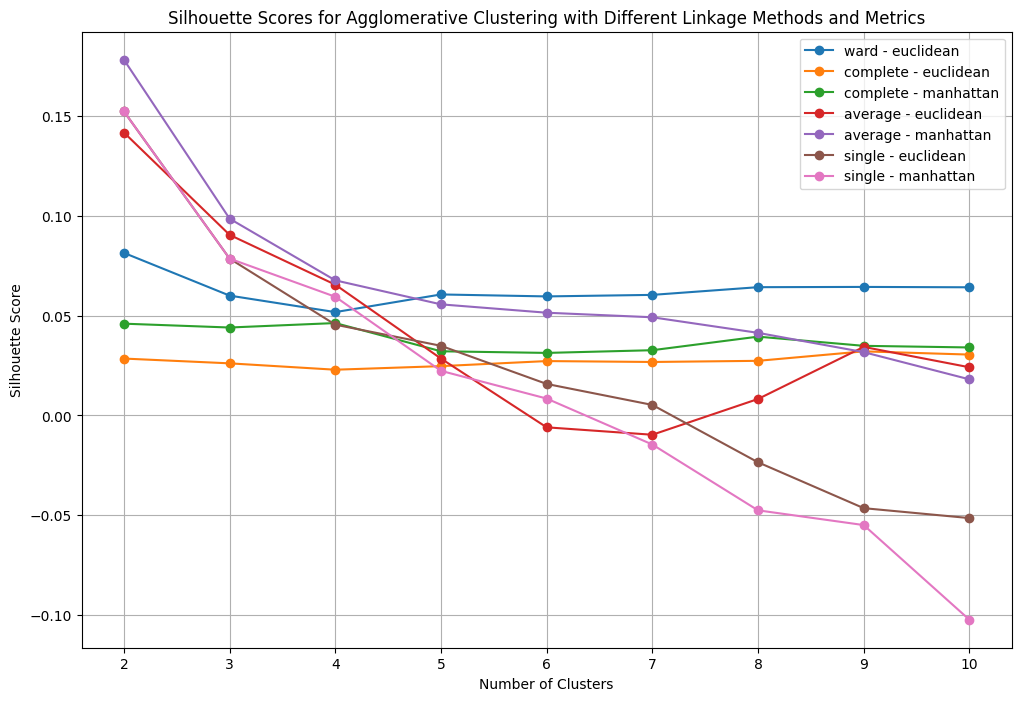

Best Silhouette Score: 0.1783692068574448
Optimal Number of Clusters: 2
Optimal Linkage Method: average
Optimal Metric: manhattan


In [93]:
# Define the range of clusters to test and linkage methods
range_n_clusters = range(2, 11)
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan']

best_silhouette_score = -1
best_n_clusters = 0
best_linkage = ''
best_metric = ''

results_for_plotting = []

for linkage_method in linkage_methods:
    for metric in metrics:
        # Skip 'ward' linkage with 'manhattan' metric as it's not supported
        if linkage_method == 'ward' and metric == 'manhattan':
            print(f"Skipping Ward linkage with Manhattan metric (not supported).")
            continue

        current_scores = []
        for n_clusters in range_n_clusters:
            agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, metric=metric)
            y_agglo = agglo.fit_predict(X_scaled)
            silhouette_avg = silhouette_score(X_scaled, y_agglo)
            current_scores.append(silhouette_avg)

            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_n_clusters = n_clusters
                best_linkage = linkage_method
                best_metric = metric
        results_for_plotting.append({
            'linkage': linkage_method,
            'metric': metric,
            'scores': current_scores
        })

# Plot the silhouette scores for each linkage method and metric combination
plt.figure(figsize=(12, 8))
for result in results_for_plotting:
    plt.plot(range_n_clusters, result['scores'], marker='o', label=f"{result['linkage']} - {result['metric']}")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Agglomerative Clustering with Different Linkage Methods and Metrics")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Silhouette Score: {best_silhouette_score}")
print(f"Optimal Number of Clusters: {best_n_clusters}")
print(f"Optimal Linkage Method: {best_linkage}")
print(f"Optimal Metric: {best_metric}")

In [95]:
# metric itu jarak antara titik dalam 1 cluster
# linkage itu jarak antar clusternya
# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage, metric=best_metric)
y_hc = agglo.fit_predict(X_scaled)

In [96]:
# Evaluation
ss = silhouette_score(X_scaled, y_hc)
print(ss)

0.1783692068574448


In [101]:
# Add the cluster labels to the original data
df_clean['Agglo'] = y_hc
# Analyze the clusters with the original values
df_clean.head()

,student_id,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended,lecture_attendance_rate,lab_attendance_rate,gender_encoded,Cluster_K-Means,Agglo
0,1,19,Male,8.0,5.7,7.4,5,30.0,36.5,2.57,12,4,6,1,0.333333,0.166667,1,1,0
1,2,21,Male,10.0,7.9,4.1,5,25.4,33.0,2.40,12,1,6,5,0.083333,0.833333,1,1,0
2,3,19,Female,7.5,1.2,0.3,5,14.4,24.8,2.99,12,0,6,0,0.000000,0.000000,0,0,0
3,4,21,Male,5.2,2.5,9.9,5,17.7,41.0,1.68,12,9,6,0,0.750000,0.000000,1,1,0
4,5,21,Female,5.9,6.3,2.0,5,23.8,31.0,2.53,12,7,6,4,0.583333,0.666667,0,0,0


In [102]:
print(df_clean['Agglo'].value_counts(dropna=False))

Agglo
0    297
1      3
Name: count, dtype: int64


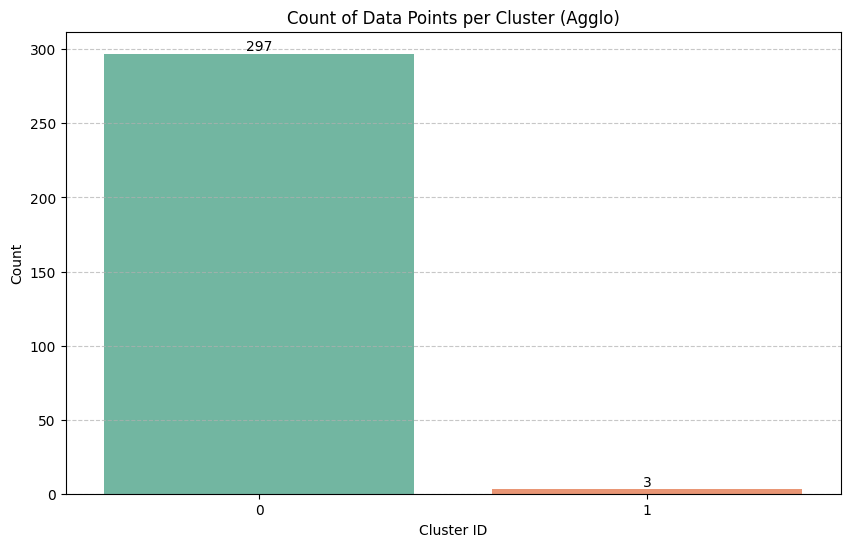

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the counts of each cluster in the 'Agglo' column of df
cluster_counts = df_clean['Agglo'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='Set2', legend=False)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (Agglo)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Summary

In [106]:
cluster_summary_kmeans = df_clean.groupby('Cluster_K-Means').agg({
    'quiz1_marks': ['mean', 'std', 'min', 'max'],
    'quiz2_marks': ['mean', 'std', 'min', 'max'],
    'quiz3_marks': ['mean', 'std', 'min', 'max'],
    'midterm_marks': ['mean', 'std', 'min', 'max'],
    'final_marks': ['mean', 'std', 'min', 'max'],
    'previous_gpa': ['mean', 'std', 'min', 'max'],
    'lecture_attendance_rate': ['mean', 'std', 'min', 'max'],
    'lab_attendance_rate': ['mean', 'std', 'min', 'max'],
    'age': ['mean', 'std', 'min', 'max'],
    'gender_encoded': ['mean', 'std', 'min', 'max']
})

cluster_summary_kmeans


quiz1_marks                      quiz2_marks                 \
                       mean       std  min   max        mean       std  min   
Cluster_K-Means                                                               
0                  7.174194  1.678854  2.8  10.0    5.936129  2.343377  0.9   
1                  7.340690  1.538014  3.6  10.0    5.792414  2.494858  0.0   

                      quiz3_marks            ... lab_attendance_rate       \
                  max        mean       std  ...                 min  max   
Cluster_K-Means                              ...                            
0                10.0    5.473548  2.768118  ...                 0.0  1.0   
1                10.0    5.464138  2.658338  ...                 0.0  1.0   

                       age                   gender_encoded               
                      mean       std min max           mean  std min max  
Cluster_K-Means                                                           
0                21.529032  2.207748  18  25            0.0  0.0   0   0  
1                21.572414  2.284443  18  25            1.0  0.0   1   1  

[2 rows x 40 columns]

In [107]:
cluster_summary_agglo = df_clean.groupby('Agglo').agg({
    'quiz1_marks': ['mean', 'std', 'min', 'max'],
    'quiz2_marks': ['mean', 'std', 'min', 'max'],
    'quiz3_marks': ['mean', 'std', 'min', 'max'],
    'midterm_marks': ['mean', 'std', 'min', 'max'],
    'final_marks': ['mean', 'std', 'min', 'max'],
    'previous_gpa': ['mean', 'std', 'min', 'max'],
    'lecture_attendance_rate': ['mean', 'std', 'min', 'max'],
    'lab_attendance_rate': ['mean', 'std', 'min', 'max'],
    'age': ['mean', 'std', 'min', 'max'],
    'gender_encoded': ['mean', 'std', 'min', 'max']
})

cluster_summary_agglo


quiz1_marks                      quiz2_marks                       \
             mean       std  min   max        mean       std  min   max   
Agglo                                                                     
0        7.249158  1.615719  2.8  10.0    5.841751  2.411741  0.0  10.0   
1        7.800000  1.252996  6.5   9.0    8.333333  1.305118  7.3   9.8   

      quiz3_marks            ... lab_attendance_rate             age  \
             mean       std  ...                 min  max       mean   
Agglo                        ...                                       
0        5.494613  2.701020  ...            0.000000  1.0  21.518519   
1        2.933333  3.056687  ...            0.833333  1.0  24.666667   

                        gender_encoded                    
            std min max           mean       std min max  
Agglo                                                     
0      2.230129  18  25       0.478114  0.500364   0   1  
1      0.577350  24  25       1.000000  0.000000   1   1  

[2 rows x 40 columns]

### KMeans Clustering Summary Profiling

| Cluster | Karakteristik                                                                                                                                                                                                                                                                        |
| ------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **0**   | Nilai kuis & midterm rata-rata **sedang** (quiz1–3 ~5.5–7), nilai final & GPA **moderate**, kehadiran kuliah & lab **rendah–sedang**, usia **21–22**, gender **0** → **“Siswa dengan performa akademik moderat dan kehadiran bervariasi.”**                                          |
| **1**   | Nilai kuis & midterm rata-rata **sedikit lebih tinggi** (quiz1–3 ~5.8–7.3), final & GPA **sedikit lebih tinggi**, kehadiran kuliah & lab **rendah–sedang**, usia **21–22**, gender **1** → **“Siswa dengan performa akademik sedikit lebih baik, tapi kehadiran masih bervariasi.”** |


### Agglomerative Clustering Summary Profiling

| Cluster | Karakteristik                                                                                                                                                                                                                                                                     |
| ------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **0**   | Nilai kuis & midterm rata-rata **sedang** (quiz1–3 ~5.5–7.2), final & GPA **moderate**, kehadiran kuliah & lab **rendah–sedang** (0–1), usia **21–22**, gender **campuran** → **“Siswa dengan performa akademik moderat dan kehadiran bervariasi, cluster lebih campur gender.”** |
| **1**   | Nilai kuis & midterm **tinggi** (quiz1–3 ~6.5–8.3), final & GPA **tinggi**, kehadiran kuliah & lab **sangat tinggi** (~0.83–1), usia **24–25**, gender **1** → **“Siswa dengan performa akademik baik, kehadiran tinggi, lebih senior, dan gender homogen.”**                     |


### Actionable Recommendations

1. Targeted Remedial Programs for “At-Risk” Students

    - Data Insight: K-Means Cluster 0 & Agglomerative Cluster 0 menunjukkan siswa dengan nilai kuis/midterm sedang, kehadiran kuliah/lab rendah–sedang, dan GPA moderat.
    - Action: Sediakan program remedial atau tutoring fokus pada materi kuis/midterm dan praktik laboratorium untuk meningkatkan pemahaman dan keterlibatan.

2. Mentoring or Honors Programs for High Achievers

    - Data Insight: Agglomerative Cluster 1 memiliki siswa dengan nilai kuis/midterm tinggi, kehadiran sangat tinggi, GPA unggul, dan usia sedikit lebih tua.

    - Action: Tawarkan program mentoring, proyek penelitian, atau honors class untuk memaksimalkan potensi akademik mereka.

3. Policies to Improve Attendance and Lab Engagement

    - Data Insight: PCA menunjukkan attendance rate (kuliah & lab) berkontribusi signifikan pada PC1, memengaruhi performa akademik.
    - Action: Implementasikan monitoring kehadiran, insentif partisipasi lab, dan aktivitas interaktif untuk meningkatkan keterlibatan praktikum.

4. Personalized Feedback Reports

    - Data Insight: Kombinasi clustering & PCA mengidentifikasi dimensi performa siswa (nilai & kehadiran).
    - Action: Kirim laporan personal tiap cluster, menyoroti kekuatan dan area untuk perbaikan agar strategi belajar lebih efektif.